<h2>RSA Cryptosystem</h2>
RSA stand for Rivest-Shamir-Adleman, the names of three famous computer scientists who invented the system for encrypting and decryting secret messages. The cryptosystem was discovered first by Clifford Cocks, a British mathematician. But his discovery was held as a classified state secret by the British government.

RSA is a public key cryptosystem that can encrypt and decrypt messages that one wishes to transmit across a channel. In a public key system, a user has two types of passwords or keys.
Public Key:  𝑝
  is a key (or passphrase) that is announced to everyone in the world. Imagine a centralized registry where I can look up your public key or anyone else's for that matter.
Private/Secret Key:  𝑠
  is a key (or passphrase) that is held secret by the user. This key is never revealed to anyone. In fact, doing so will allow them to retrieve your secrets.

The idea is that if one encrypts a message using a public key, they can decrypt it with the private key or vice-versa. In other words, for any message  𝑚, if we encrypt it with the public key
    𝖾𝗇𝖼𝗋𝗒𝗉𝗍(𝑚,𝑝)=𝑚′
 
then it can be decrypted using the secret key
    𝖽𝖾𝖼𝗋𝗒𝗉𝗍(𝑚′,𝑠)=𝑚

Encryption + Authentication/signing

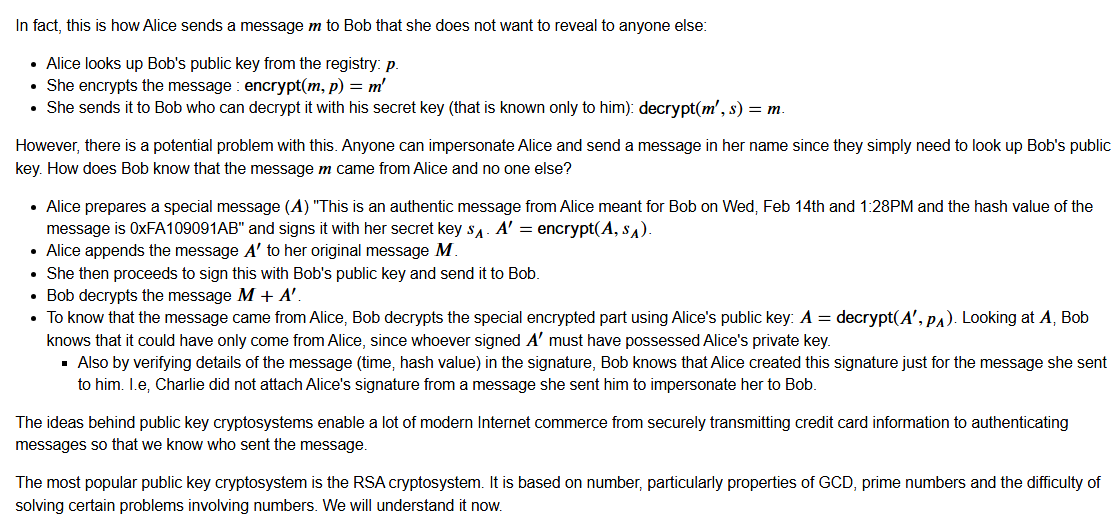


<h2>Message Encoded as Numbers</h2>
First, we will <u>convert the problem of encrypting/decrypting messages in terms of operations over numbers</u>. To do this, we have to code up messages (plain text) into a sequence of numbers that are interconvertible to the messages. One simple way to do this is to convert a given message string as a sequence of characters using the ascii code into a bunch of numbers.

Here are a couple of useful functions to convert a sequence of numbers into strings. We can also integrate some sort of "salt", scramble the message in some order to prevent some attacks based on frequency analysis and known/common ciphertexts but that is beyond the scope of this lecture.

In [2]:
# given a string s, convert it into a sequence of numbers.
# It works by taking a "block length" of 5 characters and encoding the ascii values as a 
# number in the base q number sytem.
# We take q = 101 by default.
# We convert these base-q numbers into decimals.
def convert_string_to_numbers(s, q=101 ):
    # we hard code a block length of 5 for this function
    lst = [*s] # unpack string into a list
    n = len(lst)
    assert n > 0, 'Nonempty string required'
    # ord(c) for a character c provides us its ascii value
    assert all( 32 <= ord(c) <= 126 for c in lst), 'String must have alpha numeric and space characters.'
    # pad the string with a special char so that n is a multiple of block length
    r = 0 if n%5 == 0 else 5 - (n%5)
    # chr(31) is a null character that we use to pad the message to make its size a multiple of the block length (5)
    lst += [chr(31)]*r # pad it wwith a special character ascii 31
    n = len(lst) 
    assert n%5 == 0
    msg = []
    # run through the characters 5 at a time
    for i in range(0, n, 5):
        block = lst[i:i+5]
        c = [ord(k)-31 for k in block] # subtract 31 from ascii values
        m = 0
        for i in range(4, -1, -1): # convert from base-q to decimal
            m = m * q + c[i]
        msg.append(m) # append number to message
    return msg

In [3]:
msg = convert_string_to_numbers('Hello, this is a message that needs to be encoded!!')
for j in msg:
    print(j)

8404957845
7776548846
191360744
8813990599
176922693
192316710
8812885672
6973901834
7158215288
279932690
2


In [4]:
# this function inverts the process from the function for converting string to numbers
def convert_numbers_to_strings(msg, q=101 ):
    n = len(msg)
    assert n > 0, 'Nonempty list of numbers required'
    blk_len = 5 # hard coded block length
    codes = []
    for k in msg: # each number is a decimal representation of a 5 digit base q number
        for i in range(5): # convert it back into base q
            r = k%q
            if r >= 1:
                codes.append(chr(r + 31)) # convert from ascii back into character but add 31
            k = k//q
    # convert from sequence of chars back into a string
    return ''.join(codes)
    

In [5]:
convert_numbers_to_strings(msg)

'Hello, this is a message that needs to be encoded!!'

<h2>Basics of RSA</h2>

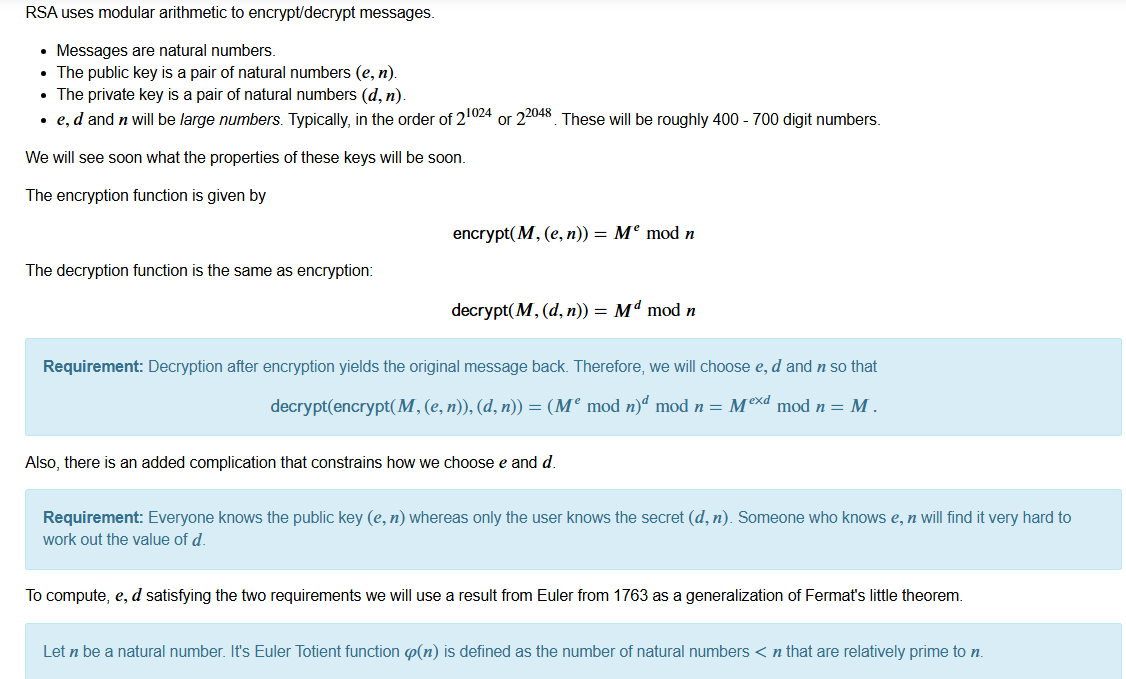

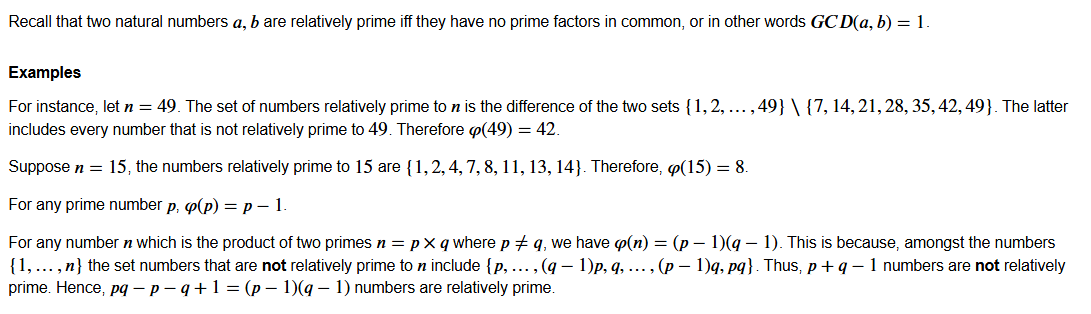

<h2> Euler's Theorem </h2>

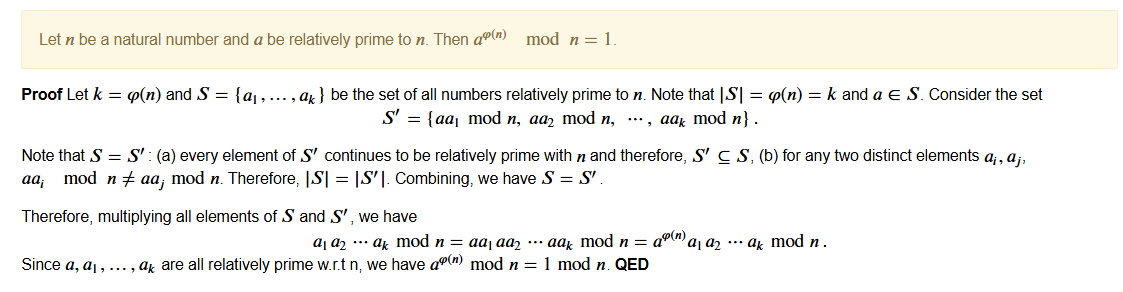

ToDo - understand proof of Euler's Totient Theorem

<h2>Designing the RSA Cryptography Scheme (Take 2)</h2>

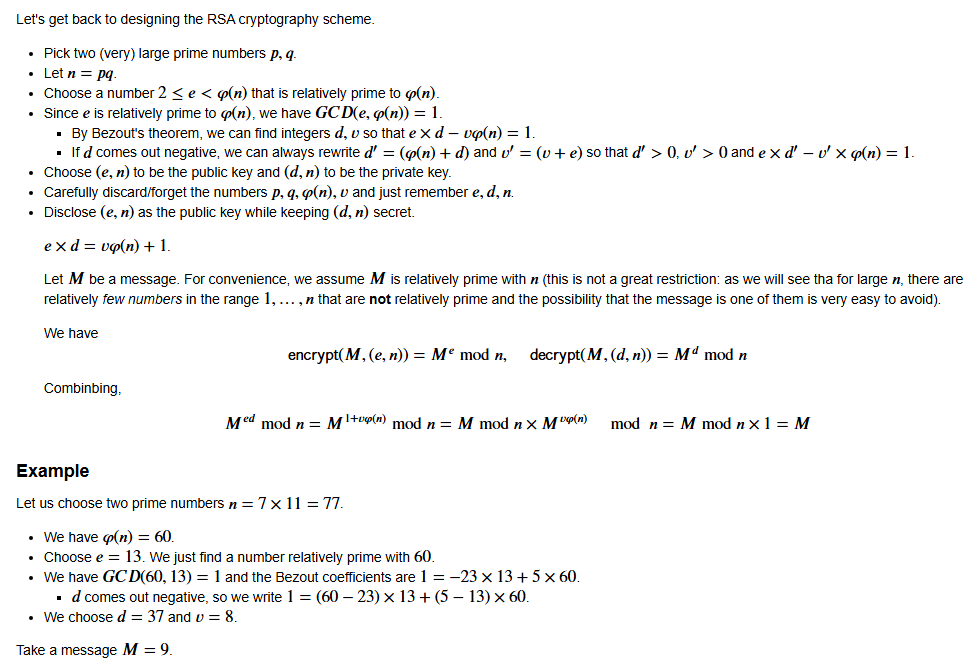

In [6]:
def encrypt_naive(M, e, n): # 
    assert 2 <= M < n
    p = 1
    for i in range(e):
        p = (p * M) % n
    return p

In [7]:
encrypt_naive(9, 13, 77) # encrypt 9 with the public key

58

In [8]:
encrypt_naive(58, 37, 77) # decrypt 9 with the private key == decryption is same as encryption for RSA just with.a different key

9

In [9]:
# Here is the code to generate private and public keys.
def extended_euclid(m, n, debug=False):
    assert m >= 1 and n >= 0 and m >= n
    m0, n0 = m, n # let's rememver the initial values
    (s, t) = (1, 0)# m = s * m0 + t * n0
    (s_hat, t_hat) = (0, 1) # n = s_hat * m0 + t_hat * n0
    while n > 0:
        assert m == s * m0 + t * n0
        assert n == s_hat * m0 + t_hat * n0
        q = m // n # compute the integer quotient 
        r = m % n # the reminder 
        # m = q * n + r, or alternatively, r = m - q * n = (s-q*s_hat) * m_0 + (t - q * t_hat)* n_0  
        a, b = (s - q*s_hat, t - q * t_hat)
        (m, n, s, t, s_hat, t_hat) = (n, r, s_hat, t_hat, a, b)
        if debug:
            print(f'GCD({m0}, {n0}) = GCD({m}, {n})')
            print(f'\t {m} = {s}*{m0} + {t} * {n0}')
            print(f'\t {n} = {s_hat}*{m0} + {t_hat} * {n0}')
    return m, s, t
        

In [25]:
(i, s, t) = extended_euclid(20, 7)
print(f"(i, s, t)=${(i, s, t)}")

(i, s, t)=$(1, -1, 3)


In [10]:
from random import randint
def generate_rsa_keys(p, q):
    assert p < q
    n = p * q
    phi = (p-1)*(q-1)
    e = None
    d = None
    for e in range(p//3, p):
        (i, s, t) = extended_euclid(phi, e)
        if i == 1:
            if t < 0:
                d = phi + t
            else:
                d = t
            break
    return (n, e, d)

    
    

In [27]:
generate_rsa_keys(3,11)

(33, 1, 1)

In [28]:
generate_rsa_keys(7, 13)

(91, 5, 29)

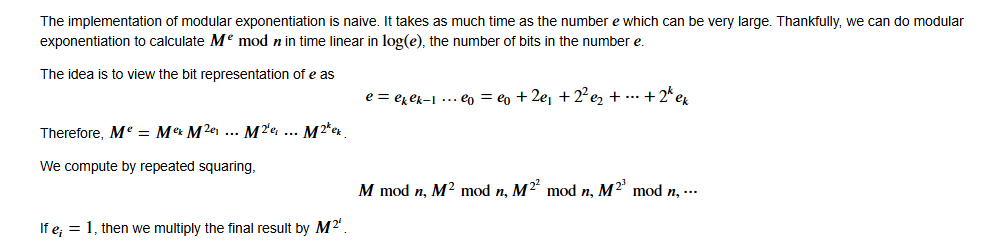

In [12]:
def modular_exp(M, e, n):
    p = 1 # this is the final result
    exp = M # this will be the exponent M^{2^i}
    while e > 0:
        b = e % 2 # extract least significant bit 
        if b == 1:
            p = (p * exp)%n
        exp = (exp * exp)%n # exp is now M^{2^{i+1}}
        e = e // 2 # integer division
    return p

In [13]:
modular_exp(9, 13, 77) # encrypt message=9 with the public key  (e,n) = (13,77)

58

In [14]:
modular_exp(58, 37, 77) # decrypt encrypted message=58 with the private key (d,n) = (37,77) to get original message (9)

9

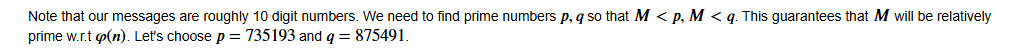

In [15]:
(n, e, d) = generate_rsa_keys(735193, 875491)
print(f'Public Key: {e, n}')
print(f'Private Key: {d, n}')

Public Key: (245071, 643654854763)
Private Key: (478235009071, 643654854763)


In [16]:
def rsa_encode(msg_list, e, n):
    rsa_lst = [modular_exp(M, e, n) for M in msg_list]
    return rsa_lst

In [17]:
orig_msg = convert_string_to_numbers('Hello, I have to say something secret!!')
print('Original message:')
print(orig_msg)
print(f'Public Key: {e, n}')
msg_rsa = rsa_encode(orig_msg, e, n)
print('RSA encoded')
print(msg_rsa)

Original message:
[8404957845, 7597868130, 8846887309, 9434293021, 7365416113, 7574504983, 8707796306, 2089659]
Public Key: (245071, 643654854763)
RSA encoded
[46264071735, 544973177667, 185197985834, 152593409466, 416635991589, 482835244299, 65259378513, 220105851236]


In [18]:
# If we tried to read the encrypted message, we get junk back.
print('RSA encoded string is')
convert_numbers_to_strings(msg_rsa)


RSA encoded string is


"2cLZG>>['u)FAg]=`aFS]ann_98,\x7f}T(*,4r_X0~"

In [19]:
msg_decode = rsa_encode(msg_rsa, d, n)
print('Decrypted message')
print(msg_decode)
convert_numbers_to_strings(msg_decode)

Decrypted message
[8404957845, 7597868130, 8846887309, 9434293021, 7365416113, 7574504983, 8707796306, 2089659]


'Hello, I have to say something secret!!'

<h2> Summary & Security of RSA </h2>

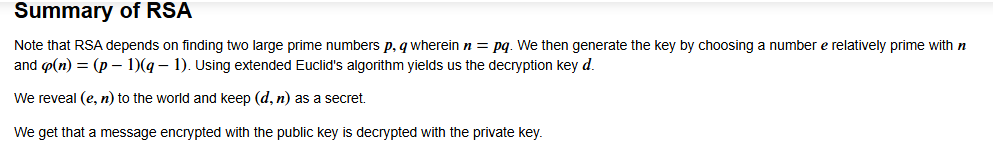
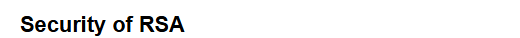
The security of a public-key cryptosystem depends on the hardness of finding the secret key just knowing public key. How does RSA fare in this respect?
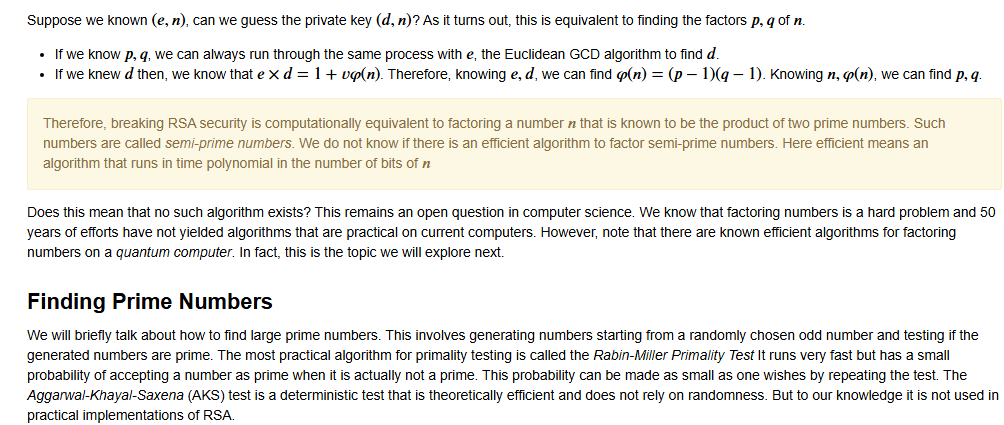

In [23]:
def emod(a,b,c):
    if b==0:
        return 1
    elif b%2==0: # even power
        d = emod(a, b/2,c)
        return (d*d)%c
    else: # odd power
        return  ((a%c)* emod(a,b-1,c))%c
    
print( f"emod = {emod(10,60,77)}")
print( f"emod = {emod(12,10,5)}")

emod = 1
emod = 4
